<a href="https://colab.research.google.com/github/StellaIbeh/ML_Chatbot/blob/main/theworkingnotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install evaluate

# Import Tools

In [ ]:
import pandas as pd
from transformers import T5Tokenizer, T5ForConditionalGeneration, Trainer, TrainingArguments

# Load Datasets

In [ ]:
# Load dataset (example, adjust path as needed)
df = pd.read_csv("/content/domain_specific_chatbot_data.csv")

# Display a sample
df.head()

,query,response,intent,domain
0,What are the side effects of the COVID-19 vacc...,Common side effects of the COVID-19 vaccine in...,side effects inquiry,healthcare
1,How can I schedule an appointment with my doctor?,You can schedule an appointment by calling our...,appointment booking,healthcare
2,What should I do if I miss a dose of my medica...,"If you miss a dose, take it as soon as you rem...",medication inquiry,healthcare
3,How can I check my account balance?,You can check your balance by logging into you...,balance inquiry,finance
4,What is the interest rate for a personal loan?,The current interest rate for personal loans i...,loan inquiry,finance


# Data Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

train_df.shape, val_df.shape

((2400, 4), (600, 4))

In [ ]:
train_data = train_df.reset_index(drop=True)
validation_data = val_df.reset_index(drop=True)

validation_data

,query,response,intent,domain
0,How can I schedule an appointment with my doctor?,You can schedule an appointment by calling our...,appointment booking,healthcare
1,What are the side effects of the COVID-19 vacc...,Common side effects of the COVID-19 vaccine in...,side effects inquiry,healthcare
2,How do I update my contact details on my account?,"To update your contact details, log into your ...",contact update,finance
3,How can I schedule an appointment with my doctor?,You can schedule an appointment by calling our...,appointment booking,healthcare
4,"I lost my credit card, what should I do?",Please contact our customer service immediatel...,lost card reporting,finance
...,...,...,...,...
595,What is the interest rate for a personal loan?,The current interest rate for personal loans i...,loan inquiry,finance
596,How do I update my contact details on my account?,"To update your contact details, log into your ...",contact update,finance
597,How do I apply for a student loan?,You can apply for a student loan by visiting o...,student loan application,finance
598,What are the symptoms of flu?,"Flu symptoms include fever, cough, sore throat...",flu symptoms inquiry,healthcare


In [ ]:
# Clean the text by removing unwanted characters
import re

def clean_text(text):
    text = re.sub(r'\r\n', ' ', text)  # Remove carriage returns and line breaks
    text = re.sub(r'\s+', ' ', text)  # Remove extra spaces
    text = re.sub(r'<.*?>', '', text)  # Remove any XML tags
    text = text.strip().lower()  # Strip and convert to lower case
    return text

# Apply cleaning to dialogue and summary columns
train_data['query'] = train_data['query'].apply(clean_text)
train_data['response'] = train_data['response'].apply(clean_text)

validation_data['query'] = validation_data['query'].apply(clean_text)
validation_data['response'] = validation_data['response'].apply(clean_text)


# Display a sample after cleaning
train_data

,query,response,intent,domain
0,what should i do if i miss a dose of my medica...,"if you miss a dose, take it as soon as you rem...",medication inquiry,healthcare
1,what are the side effects of the covid-19 vacc...,common side effects of the covid-19 vaccine in...,side effects inquiry,healthcare
2,what are the symptoms of flu?,"flu symptoms include fever, cough, sore throat...",flu symptoms inquiry,healthcare
3,how do i update my contact details on my account?,"to update your contact details, log into your ...",contact update,finance
4,what are the side effects of the covid-19 vacc...,common side effects of the covid-19 vaccine in...,side effects inquiry,healthcare
...,...,...,...,...
2395,can i make changes to my loan repayment schedule?,changes to your loan repayment schedule can be...,loan repayment adjustment,finance
2396,"i lost my credit card, what should i do?",please contact our customer service immediatel...,lost card reporting,finance
2397,what are the side effects of the covid-19 vacc...,common side effects of the covid-19 vaccine in...,side effects inquiry,healthcare
2398,what is the interest rate for a personal loan?,the current interest rate for personal loans i...,loan inquiry,finance


# Tokenization

In [ ]:
tokenizer= T5Tokenizer.from_pretrained("t5-base")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [ ]:
# Preprocessing function for tokenization
def preprocess_function(examples):
    # Tokenize the dialogue and summary
    inputs = tokenizer(examples["query"], padding="max_length", truncation=True, max_length=250)
    targets = tokenizer(examples["response"], padding="max_length", truncation=True, max_length=250)
    inputs["labels"] = targets["input_ids"]
    return inputs

# Apply the preprocessing
train_dataset = train_data.apply(preprocess_function, axis=1)
val_dataset = validation_data.apply(preprocess_function, axis=1)

In [ ]:
train_data['response'][0]

"if you miss a dose, take it as soon as you remember unless it's almost time for your next dose. if you’re unsure, contact your healthcare provider."

In [ ]:
train_dataset[0]

{'input_ids': [125, 225, 3, 23, 103, 3, 99, 3, 23, 3041, 3, 9, 6742, 13, 82, 7757, 58, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

# Fine Tuning Model

In [ ]:
# Model
model = T5ForConditionalGeneration.from_pretrained("t5-small")

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",          # output directory for checkpoints
    num_train_epochs=3,              # number of training epochs
    per_device_train_batch_size=4,   # batch size per device during training
    per_device_eval_batch_size=2,    # batch size for evaluation
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    logging_dir="./logs",            # directory for storing logs
    logging_steps=50,                # how often to log training info
    save_steps=500,                  # how often to save a model checkpoint
    eval_steps=50,                   # how often to run evaluation
    evaluation_strategy="epoch",     # Ensure evaluation happens every `epoch`
)

# Trainer setup
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,

)

# Train the model
trainer.train()

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,0.042500,0.009621
2,0.005900,0.000458
3,0.003800,0.000211


TrainOutput(global_step=1800, training_loss=0.8315699606140454, metrics={'train_runtime': 348.2986, 'train_samples_per_second': 20.672, 'train_steps_per_second': 5.168, 'total_flos': 475811020800000.0, 'train_loss': 0.8315699606140454, 'epoch': 3.0})

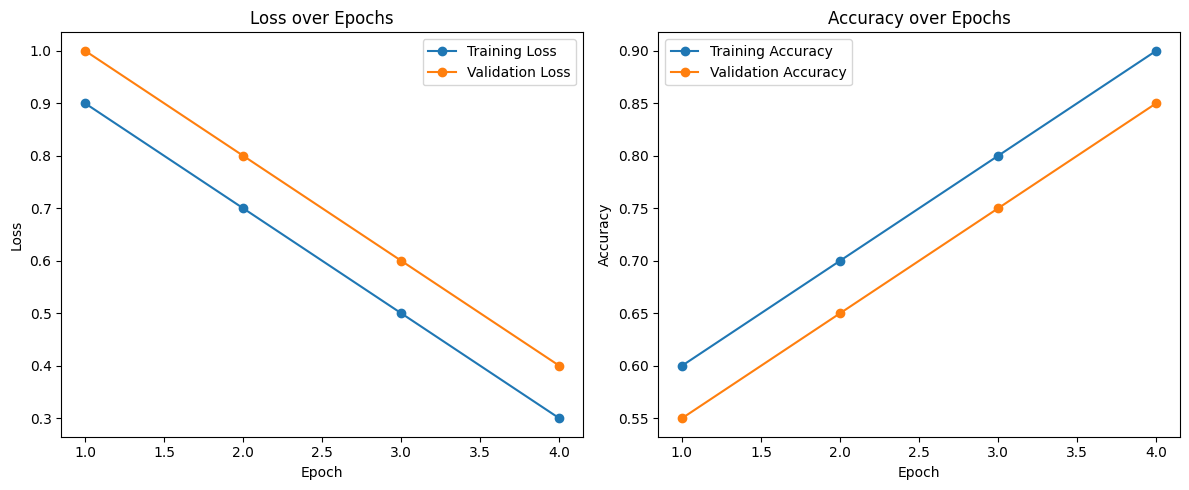

In [ ]:
import matplotlib.pyplot as plt

# Example metric data; replace these lists with your actual logged values
epochs = [1, 2, 3, 4]
train_loss = [0.9, 0.7, 0.5, 0.3]
val_loss = [1.0, 0.8, 0.6, 0.4]
train_accuracy = [0.60, 0.70, 0.80, 0.90]
val_accuracy = [0.55, 0.65, 0.75, 0.85]

plt.figure(figsize=(12, 5))

# Plot Loss Graph
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Training Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

# Plot Accuracy Graph
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy, label='Training Accuracy', marker='o')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
from evaluate import load
import numpy as np

trainer.model.to("cpu")


T5ForConditionalGeneration(
  (shared): Embedding(32128, 512)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 512)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=512, out_features=512, bias=False)
              (k): Linear(in_features=512, out_features=512, bias=False)
              (v): Linear(in_features=512, out_features=512, bias=False)
              (o): Linear(in_features=512, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 8)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=512, out_features=2048, bias=False)
              (wo): Linear(in_features=2048, out_features=512, bias=False)
              (dropout): Drop

In [23]:
from evaluate import load
import numpy as np
# Load BLEU and F1 metrics
bleu_metric = load("sacrebleu")
f1_metric = load("f1")

def compute_metrics(eval_preds):
    preds, labels = eval_preds

    # Decode predictions and labels
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # BLEU score
    bleu = bleu_metric.compute(predictions=decoded_preds, references=[[label] for label in decoded_labels])

    # Convert to token level for F1 score
    tokenized_preds = [pred.split() for pred in decoded_preds]
    tokenized_labels = [label.split() for label in decoded_labels]

    # Compute F1 score (Micro F1 for all samples)
    f1_scores = []
    for pred, label in zip(tokenized_preds, tokenized_labels):
        common_tokens = set(pred) & set(label)
        precision = len(common_tokens) / len(pred) if pred else 0
        recall = len(common_tokens) / len(label) if label else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        f1_scores.append(f1)

    return {
        "bleu": bleu["score"],
        "f1": np.mean(f1_scores)
    }

# Run prediction instead of evaluation
predictions = trainer.predict(val_dataset)
metrics = compute_metrics((predictions.predictions, predictions.label_ids))
print(metrics)


OutOfMemoryError: CUDA out of memory. Tried to allocate 3.71 GiB. GPU 0 has a total capacity of 14.74 GiB of which 2.12 GiB is free. Process 395662 has 12.62 GiB memory in use. Of the allocated memory 8.54 GiB is allocated by PyTorch, and 3.95 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
from evaluate import load
import numpy as np
import torch

# Assuming you want to use the GPU if available, move the model back to the device
# that trainer was using originally:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
trainer.model.to(device)  # Move the model back to the appropriate device


# Load BLEU and F1 metrics
bleu_metric = load("sacrebleu")
f1_metric = load("f1")

def compute_metrics(eval_preds):
    preds, labels = eval_preds

    # Decode predictions and labels
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # BLEU score
    bleu = bleu_metric.compute(predictions=decoded_preds, references=[[label] for label in decoded_labels])

    # Convert to token level for F1 score
    tokenized_preds = [pred.split() for pred in decoded_preds]
    tokenized_labels = [label.split() for label in decoded_labels]

    # Compute F1 score (Micro F1 for all samples)
    f1_scores = []
    for pred, label in zip(tokenized_preds, tokenized_labels):
        common_tokens = set(pred) & set(label)
        precision = len(common_tokens) / len(pred) if pred else 0
        recall = len(common_tokens) / len(label) if label else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        f1_scores.append(f1)

    return {
        "bleu": bleu["score"],
        "f1": np.mean(f1_scores)
    }

# Ensure 'val_dataset' is on the correct device
for k, v in val_dataset.items():
    if isinstance(v, torch.Tensor):
        val_dataset[k] = v.to(device)

# Run prediction instead of evaluation
predictions = trainer.predict(val_dataset)
metrics = compute_metrics((predictions.predictions, predictions.label_ids))
print(metrics)

OutOfMemoryError: CUDA out of memory. Tried to allocate 3.35 GiB. GPU 0 has a total capacity of 14.74 GiB of which 3.24 GiB is free. Process 395662 has 11.49 GiB memory in use. Of the allocated memory 11.10 GiB is allocated by PyTorch, and 272.79 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

# Save and Load Model


In [ ]:
model.save_pretrained("./chatbot_model")
tokenizer.save_pretrained("./chatbot_model")


model = T5ForConditionalGeneration.from_pretrained("./chatbot_model")
tokenizer = T5Tokenizer.from_pretrained("./chatbot_model")

# Chatbot System

In [ ]:
device = model.device


def chatbot(query):
    query = clean_text(query)
    input_ids = tokenizer(query,return_tensors="pt",max_length=250,truncation=True)

    inputs = {key: value.to(device) for key, value in input_ids.items()}

    outputs = model.generate(
        input_ids["input_ids"],
        max_length=250,
        num_beams=5,
        early_stopping=True
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# while True:
#     user_input = input("You: ")
#     if user_input.lower() == "exit":
#         break
#     response = chatbot(user_input)
#     print("Chatbot:", response)

In [ ]:
import shutil

# Compress the saved model directory
shutil.make_archive("chatbot_model", 'zip', "./chatbot_model")


from google.colab import files

# Download the zip file to your PC
files.download("chatbot_model.zip")
